# Индивидуальное задание 3
## «Простейшая задача теории оптимального управления»

> Работу выполнил  
> студент 2 курса  
> ФМ/О ПМИ-1-2024 НМ  
> Усов Лев  

Вариант 9

Дано:


$$ 
\begin{equation*}
 \begin{cases}
   \dot{x}_1=a_{11}x_1+a_{12}x_2+u_1,\\
   \dot{x}_2=a_{21}x_1+a_{22}x_2+u_2,\\
 \end{cases}
\end{equation*}
$$
$$ 
\left(   
\begin{aligned}
x_1~(0)\\
x_2~(0)
\end{aligned}
\right) = 
\left(   
\begin{aligned}
0\\
0
\end{aligned}
\right) ,~~t \in[0,1]
$$
$$
\begin{aligned}
a_{11}=-1& \\
a_{12}=-2& \\
a_{21}=-2& \\
a_{22}=2& \\
\end{aligned}
$$
$$ 
u=
\left(   
\begin{aligned}
u_1\\
u_2
\end{aligned}
\right) \in P =
R^2
$$
$$
I[u(\cdot)]=\int_0^1[u_1^2(\tau)+u_2^2(\tau)]d \tau +x_1(1)+x_2(1) \rightarrow min
$$

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Требуется:
1. Определить оптимальное управление и построить оптимальную траекторию.
2. Вычислить значение функционала на оптимальной паре и сравнить с его значением на триви-
альном управлении.
3. Проанализировать поведение функции Л.С. Понтрягина вдоль стационарной пары

In [2]:
# Параметры системы
A = np.array([[-1, -2],
              [-2,  2]])

# Аналитические выражения для сопряжённых переменных и управления
def psi(t):
    """Возвращает вектор psi(t) = [psi1, psi2]"""
    # Используем ранее полученные формулы: psi1 = 1.2*exp(2*(t-1)) - 0.2*exp(3*(1-t))
    # psi2 = 0.6*exp(2*(t-1)) + 0.4*exp(3*(1-t))
    exp2 = np.exp(2*(t-1))
    exp3 = np.exp(3*(1-t))
    psi1 = 1.2 * exp2 - 0.2 * exp3
    psi2 = 0.6 * exp2 + 0.4 * exp3
    return np.array([psi1, psi2])

def u_opt(t):
    """Оптимальное управление u(t) = -psi(t)/2"""
    return -psi(t) / 2.0

# Правая часть системы dx/dt = A x + u(t)
def system(t, x):
    return A @ x + u_opt(t)

/tmp/ipykernel_18720/790536760.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  J_int = np.trapz(integrand, t)  # численное интегрирование методом трапеций


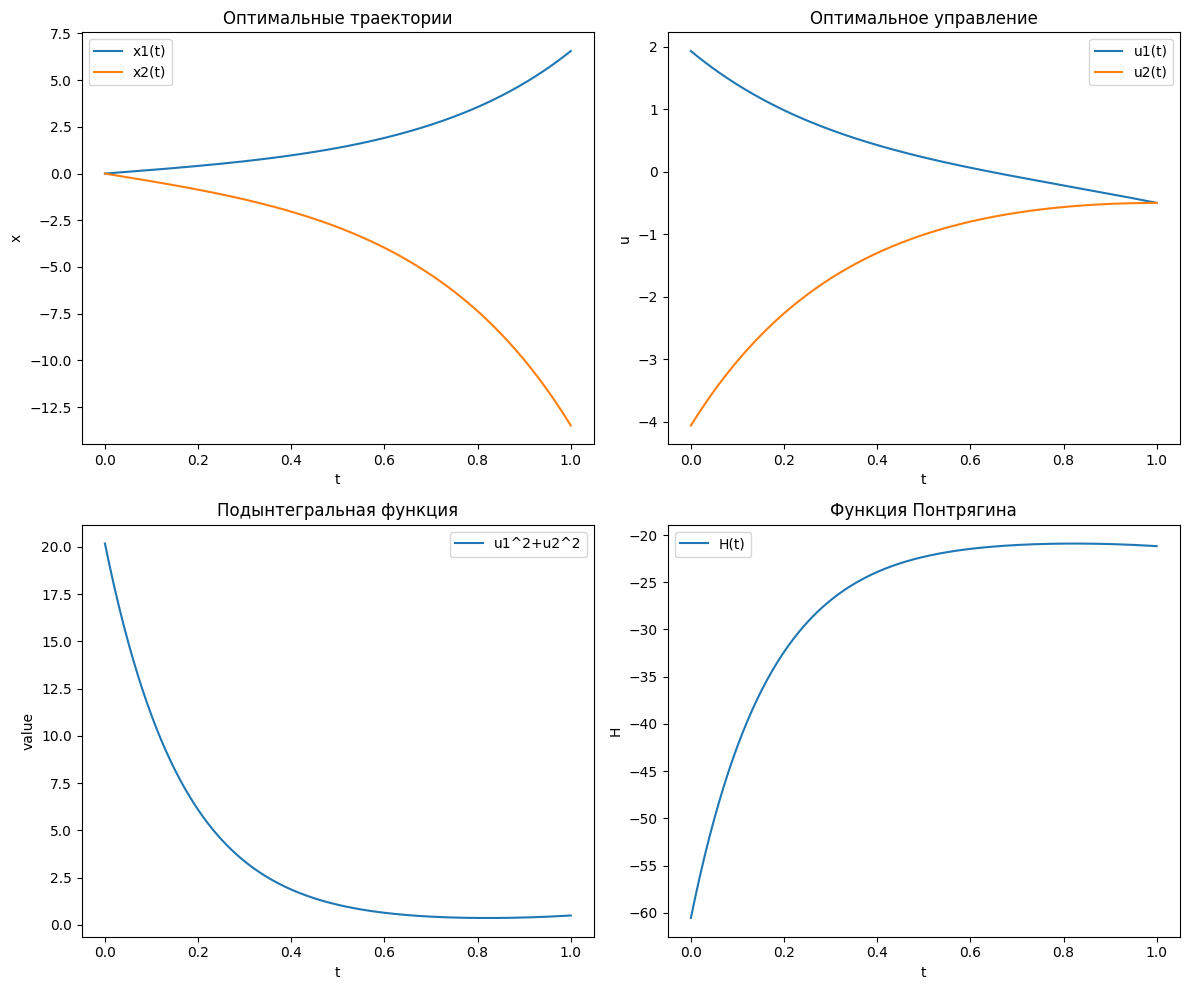

Значение функционала при оптимальном управлении: J_opt = -3.463307
Значение функционала при тривиальном управлении (u=0): J_triv = 0.0
Терминальная часть: x1(1)+x2(1) = -6.927578
Интегральная часть: ∫(u1^2+u2^2) dt = 3.464271
Функция Понтрягина: среднее значение = -27.174768, стандартное отклонение = 9.529629


In [ ]:
# Начальные условия
x0 = [0.0, 0.0]
t_span = (0, 1)
t_eval = np.linspace(0, 1, 200)

# Численное интегрирование
sol = solve_ivp(system, t_span, x0, t_eval=t_eval, method='RK45')

# Извлекаем решение
t = sol.t
x1 = sol.y[0]
x2 = sol.y[1]

# Вычисляем управление на сетке
u1 = np.array([u_opt(ti)[0] for ti in t])
u2 = np.array([u_opt(ti)[1] for ti in t])

# Вычисляем функционал: интеграл от (u1^2+u2^2) dt + x1(1)+x2(1)
integrand = u1**2 + u2**2
J_int = np.trapz(integrand, t)  # численное интегрирование методом трапеций
J_term = x1[-1] + x2[-1]        # терминальная часть
J_opt = J_int + J_term

# Для тривиального управления u=0 получаем x=0 всюду, J_triv = 0
J_triv = 0.0

# Вычисляем функцию Понтрягина H = psi'*(A x + u) - (u1^2+u2^2)
H_vals = []
for i in range(len(t)):
    ps = psi(t[i])
    xs = np.array([x1[i], x2[i]])
    us = np.array([u1[i], u2[i]])
    H = ps @ (A @ xs + us) - (us[0]**2 + us[1]**2)
    H_vals.append(H)

# Построение графиков
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.plot(t, x1, label='x1(t)')
plt.plot(t, x2, label='x2(t)')
plt.xlabel('t')
plt.ylabel('x')
plt.legend()
plt.title('Оптимальные траектории')

plt.subplot(2, 2, 2)
plt.plot(t, u1, label='u1(t)')
plt.plot(t, u2, label='u2(t)')
plt.xlabel('t')
plt.ylabel('u')
plt.legend()
plt.title('Оптимальное управление')

plt.subplot(2, 2, 3)
plt.plot(t, integrand, label='u1^2+u2^2')
plt.xlabel('t')
plt.ylabel('value')
plt.legend()
plt.title('Подынтегральная функция')

plt.subplot(2, 2, 4)
plt.plot(t, H_vals, label='H(t)')
plt.xlabel('t')
plt.ylabel('H')
plt.legend()
plt.title('Функция Понтрягина')

plt.tight_layout()
plt.show()

# Вывод результатов
print(f"Значение функционала при оптимальном управлении: J_opt = {J_opt:.6f}")
print(f"Значение функционала при тривиальном управлении (u=0): J_triv = {J_triv}")
print(f"Терминальная часть: x1(1)+x2(1) = {x1[-1]+x2[-1]:.6f}")
print(f"Интегральная часть: ∫(u1^2+u2^2) dt = {J_int:.6f}")
print(f"Функция Понтрягина: среднее значение = {np.mean(H_vals):.6f}, "
      f"стандартное отклонение = {np.std(H_vals):.6f}")